# Retention Radar – Customer Churn Prediction & Insight Analysis

## Project Overview

Customer churn occurs when a customer stops using a company's products or services. Predicting churn can help businesses identify customers at risk of leaving and improve customer retention.

This project analyzes customer data and develops a Machine Learning classification model to predict customer churn.

The project covers data preprocessing, exploratory data analysis (EDA), visualization, model development, evaluation, and feature importance analysis.

## Problem Statement

Customer churn can negatively affect a business's revenue and growth.

The goal of this project is to identify factors associated with churn and build a Machine Learning model that can predict customers who are likely to churn..

## Project Objective

- Analyze customer churn patterns.
- Identify important factors related to churn.
- Build and compare Machine Learning models.
- Select the best-performing model for churn prediction.

## 3. Dataset Description

The dataset contains customer-related information that will be used to analyze customer behavior and predict customer churn.

The target variable is **Churn**, which indicates whether a customer has left the company or continues to use the service.

The dataset will be explored and prepared before applying Machine Learning models.

In [1]:

# 4. Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:

# 5. Load the Dataset


df = pd.read_csv("customer_churn.csv")

print("Dataset loaded successfully!")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully!
Number of rows: 3941
Number of columns: 11


In [3]:

# 6. Preview the Dataset


print("First 5 rows of the dataset:")
display(df.head())

print("\nLast 5 rows of the dataset:")
display(df.tail())

First 5 rows of the dataset:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0



Last 5 rows of the dataset:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1
3940,2.0,7.0,3,Laptop & Accessory,5,Married,1,0,2.0,153.73,0


In [4]:

# 7. Understand Dataset Structure


print("Dataset Information:")


df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [5]:
# 8. Check Missing Values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64


In [6]:
# 9. Check Duplicate Rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 671


In [7]:
# 10. Inspect Duplicate Rows

duplicates = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicates))
print("\nSample duplicate rows:")

display(duplicates.head(10))

Total duplicate rows: 1342

Sample duplicate rows:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
7,1.0,11.0,4,Mobile Phone,5,Single,3,0,1.0,154.73,1
8,11.0,12.0,4,Mobile Phone,3,Married,2,0,4.0,137.02,0
11,16.0,20.0,2,Laptop & Accessory,5,Married,7,0,1.0,180.38,0
25,18.0,26.0,3,Laptop & Accessory,3,Single,9,0,1.0,148.50,0
26,16.0,17.0,3,Fashion,3,Married,2,0,9.0,175.10,0
29,1.0,17.0,5,Fashion,5,Married,11,0,NaN,228.06,1
31,30.0,11.0,4,Fashion,4,Married,3,1,4.0,205.52,0
32,11.0,17.0,2,Fashion,1,Married,3,1,9.0,262.44,0
34,0.0,NaN,4,Mobile,1,Married,6,0,3.0,123.67,1


In [8]:
# 11. Record Original Dataset Size

original_rows = df.shape[0]

print("Original number of rows:", original_rows)

Original number of rows: 3941


In [9]:
# 12. Remove Duplicate Rows

df = df.drop_duplicates()

print("Duplicate rows removed successfully!")
print("Rows after removing duplicates:", df.shape[0])
print("Rows removed:", original_rows - df.shape[0])

Duplicate rows removed successfully!
Rows after removing duplicates: 3270
Rows removed: 671


In [10]:
# 13. Recheck Missing Values

missing_values = df.isnull().sum()

print("Missing values after removing duplicates:")
print(missing_values)

Missing values after removing duplicates:
Tenure                      160
WarehouseToHome             135
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           181
CashbackAmount                0
Churn                         0
dtype: int64


In [11]:
# 14. Handle Missing Values

numeric_columns = ["Tenure", "WarehouseToHome", "DaySinceLastOrder"]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values handled successfully!")
print(df[numeric_columns].isnull().sum())

Missing values handled successfully!
Tenure               0
WarehouseToHome      0
DaySinceLastOrder    0
dtype: int64


In [12]:
# 15. Statistical Summary

df.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000
mean,10.132110,15.406728,3.676453,3.020795,4.222936,0.281651,4.459939,177.417670,0.163303
std,8.440368,8.404449,1.017390,1.395113,2.623195,0.449873,3.609590,49.310647,0.369698
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.892500,0.000000
50%,9.000000,13.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.885000,0.000000
75%,15.000000,20.000000,4.000000,4.000000,6.000000,1.000000,7.000000,197.137500,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


Churn distribution:
Churn
0    2736
1     534
Name: count, dtype: int64


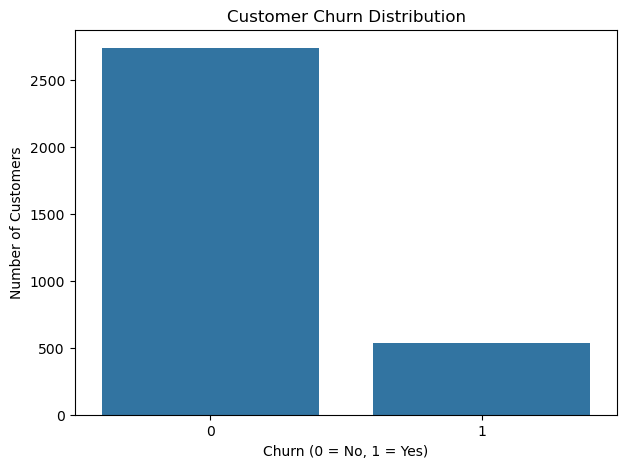

In [13]:
# 16. Analyze Churn Distribution

churn_counts = df["Churn"].value_counts()

print("Churn distribution:")
print(churn_counts)

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The dataset contains 2,736 non-churned customers and 534 churned customers. Around 16.3% of customers have churned.

### Business Insight

The target variable is imbalanced, with more non-churned customers than churned customers. Therefore, precision, recall, and F1-score should also be considered along with accuracy.

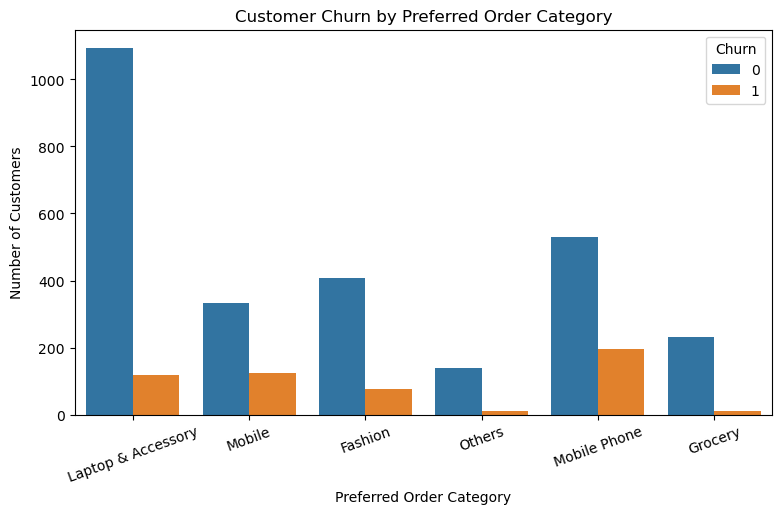

In [14]:
# 17. Churn by Preferred Order Category

plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="PreferedOrderCat", hue="Churn")

plt.title("Customer Churn by Preferred Order Category")
plt.xlabel("Preferred Order Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

### Observation

The chart compares customer churn across different preferred order categories. It helps us identify how the number of churned and non-churned customers varies across product categories.

### Business Insight

 Categories showing a relatively higher proportion of churned customers may require further investigation to understand customer preferences and improve retention strategies.

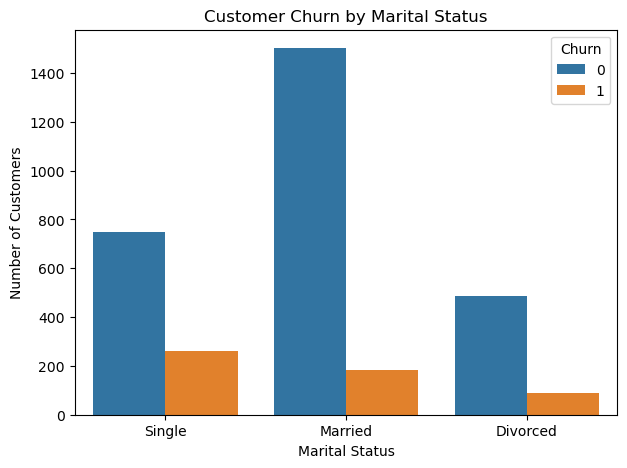

In [15]:
# 18. Churn by Marital Status

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="MaritalStatus", hue="Churn")

plt.title("Customer Churn by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The chart compares customer churn across different marital status groups. It shows how churned and non-churned customers are distributed among the different categories.

### Business Insight

Marital status may provide some additional information about customer churn behavior. However, it should be considered along with other factors such as satisfaction, complaints, tenure, and customer purchasing behavior rather than being used as a standalone factor.

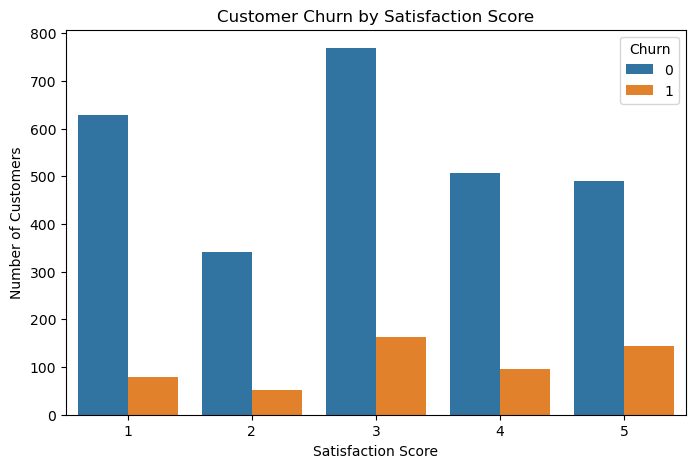

In [16]:
# 19. Churn by Satisfaction Score

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="SatisfactionScore", hue="Churn")

plt.title("Customer Churn by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The chart compares customer churn across different satisfaction score levels. It helps us understand how churn varies among customers with different levels of satisfaction.

### Business Insight

Customer satisfaction is an important factor in understanding churn. Lower satisfaction levels may indicate a higher risk of customers leaving the company. Therefore, improving customer satisfaction can be an important part of customer retention strategies.

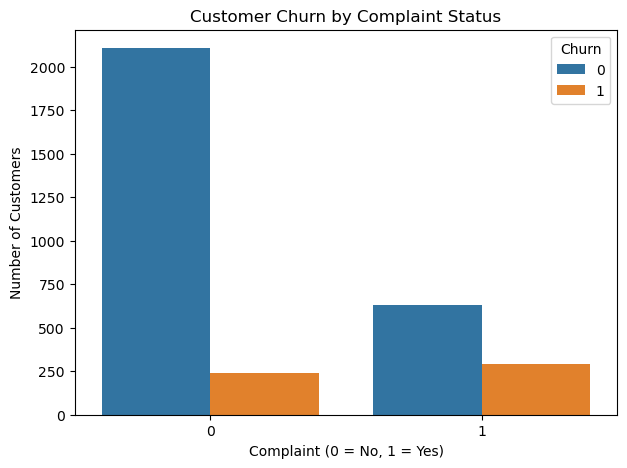

In [17]:
# 20. Churn by Customer Complaints

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Complain", hue="Churn")

plt.title("Customer Churn by Complaint Status")
plt.xlabel("Complaint (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

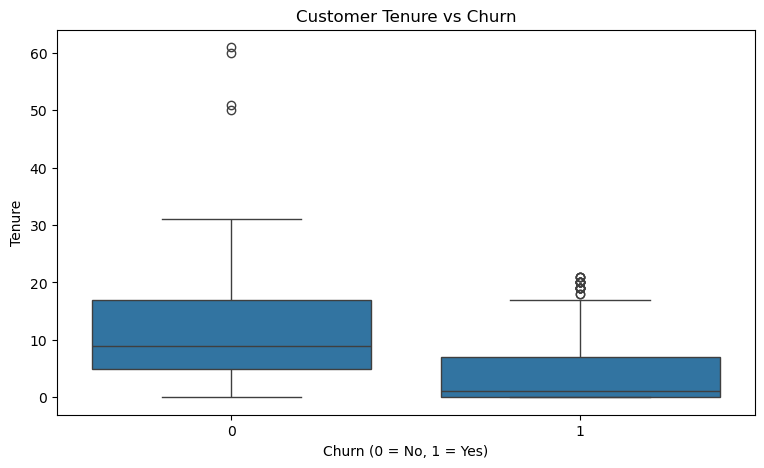

In [18]:
# 21. Churn by Customer Tenure

plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x="Churn", y="Tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure")

plt.show()

### Observation

The box plot compares the tenure of customers who churned and those who did not churn. It helps us understand whether customer tenure differs between the two groups.

### Business Insight

Customer tenure can be an important factor in understanding churn behavior. The difference in tenure between churned and non-churned customers can help identify whether newer or longer-term customers are more likely to leave.

In [19]:
# 22. Churn Rate by Preferred Order Category

category_churn = (
    df.groupby("PreferedOrderCat")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

print("Churn rate by preferred order category:")
print((category_churn * 100).round(2))

Churn rate by preferred order category:
PreferedOrderCat
Mobile                27.07
Mobile Phone          26.90
Fashion               15.50
Laptop & Accessory     9.81
Others                 7.38
Grocery                4.15
Name: Churn, dtype: float64


### Observation

Mobile has the highest churn rate at 27.07%, followed closely by Mobile Phone at 26.90%. Fashion has a churn rate of 15.50%, while Laptop & Accessory, Others, and Grocery have lower churn rates of 9.81%, 7.38%, and 4.15% respectively.

### Business Insight

Customers purchasing mobile-related products show a noticeably higher churn rate compared with other product categories. This suggests that mobile-related customers may require further investigation and targeted retention strategies.

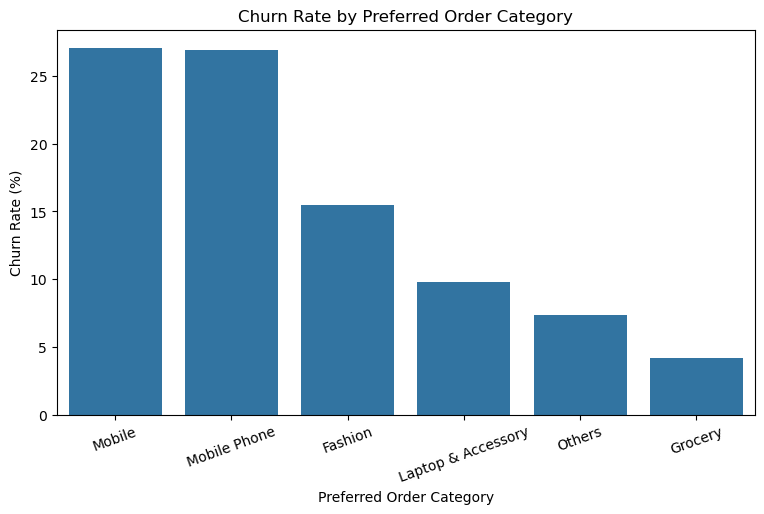

In [20]:
# 23. Visualize Churn Rate by Preferred Order Category

plt.figure(figsize=(9, 5))

sns.barplot(
    x=category_churn.index,
    y=category_churn.values * 100
)

plt.title("Churn Rate by Preferred Order Category")
plt.xlabel("Preferred Order Category")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [21]:
# 24. Churn Rate by Satisfaction Score

satisfaction_churn = (
    df.groupby("SatisfactionScore")["Churn"]
    .mean()
    .sort_index()
)

print("Churn rate by satisfaction score:")
print((satisfaction_churn * 100).round(2))

Churn rate by satisfaction score:
SatisfactionScore
1    11.17
2    13.01
3    17.49
4    15.89
5    22.83
Name: Churn, dtype: float64


### Observation

Churn rate is highest for customers with a satisfaction score of 5 (22.83%) and lowest for score 1 (11.17%). The relationship is not simply linear.

### Business Insight

Satisfaction score alone does not explain churn. Other customer factors should also be considered.

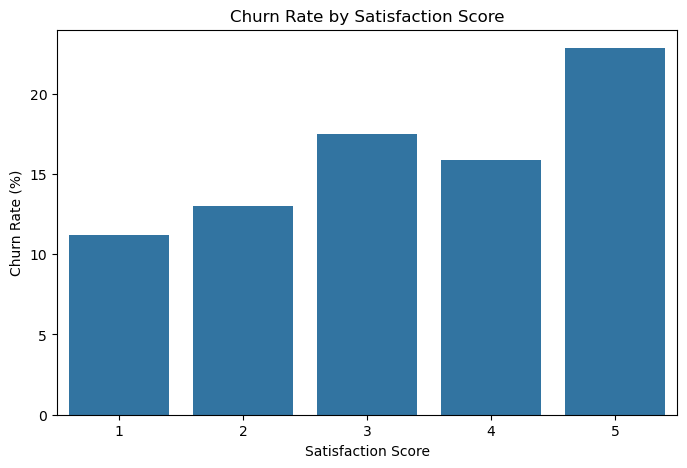

In [22]:
# 25. Visualize Churn Rate by Satisfaction Score

plt.figure(figsize=(8, 5))

sns.barplot(
    x=satisfaction_churn.index,
    y=satisfaction_churn.values * 100
)

plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")

plt.show()

In [23]:
# 26. Churn Rate by Complaint Status

complaint_churn = (
    df.groupby("Complain")["Churn"]
    .mean()
)

print("Churn rate by complaint status:")
print((complaint_churn * 100).round(2))

Churn rate by complaint status:
Complain
0    10.26
1    31.81
Name: Churn, dtype: float64


### Observation

Customers who complained have a much higher churn rate (31.81%) than customers who did not complain (10.26%).

### Business Insight

Customer complaints appear to be strongly associated with churn. Improving complaint resolution and customer support may help reduce churn.

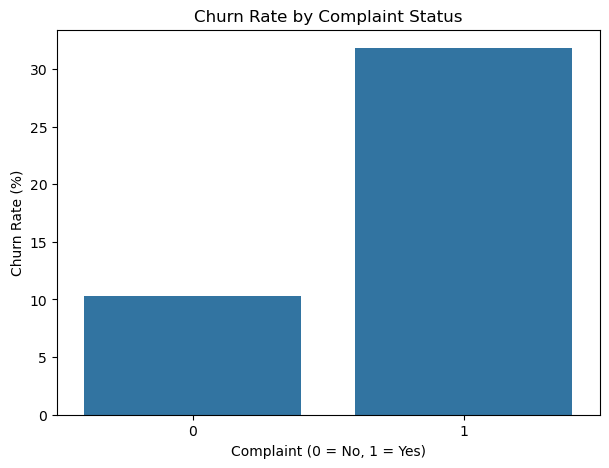

In [24]:
# 27. Visualize Churn Rate by Complaint Status

plt.figure(figsize=(7, 5))

sns.barplot(
    x=complaint_churn.index,
    y=complaint_churn.values * 100
)

plt.title("Churn Rate by Complaint Status")
plt.xlabel("Complaint (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")

plt.show()

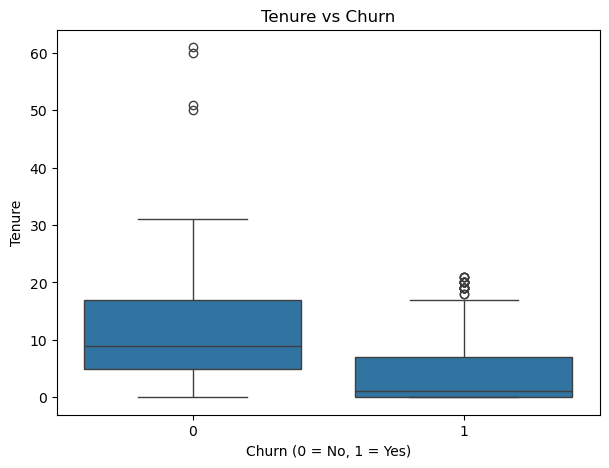

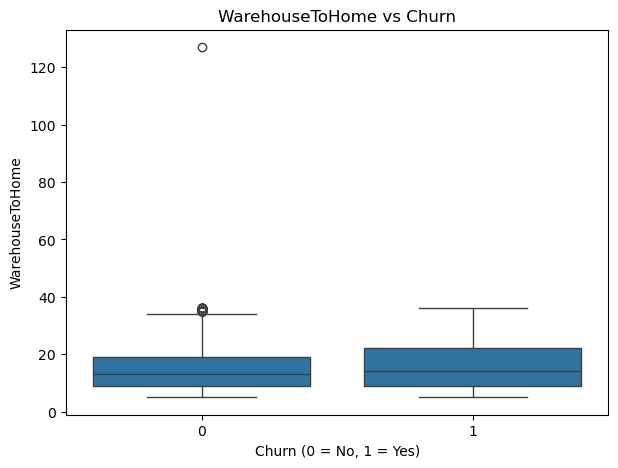

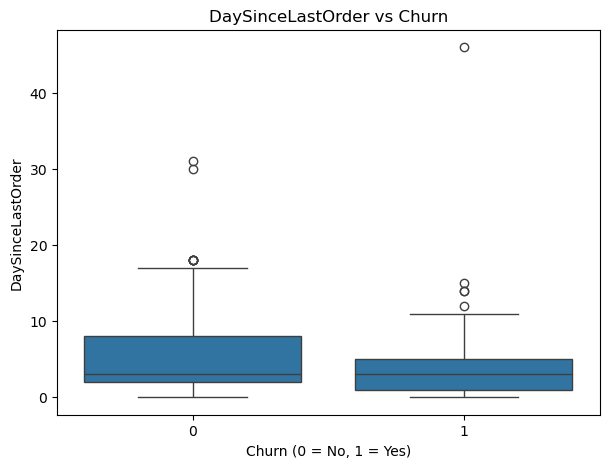

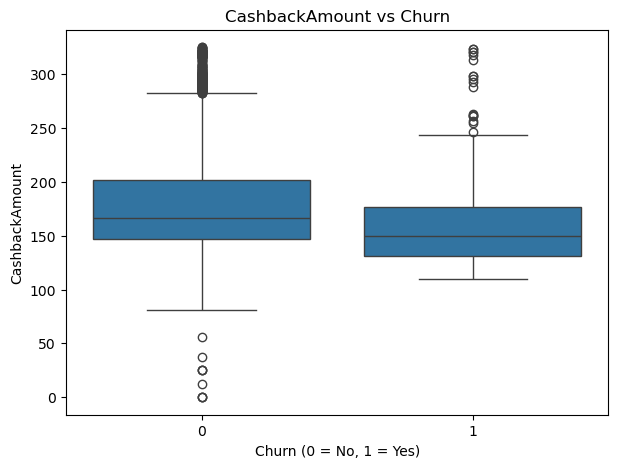

In [25]:
# 28. Numerical Features vs Churn

numerical_features = [
    "Tenure",
    "WarehouseToHome",
    "DaySinceLastOrder",
    "CashbackAmount"
]

for feature in numerical_features:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(data=df, x="Churn", y=feature)
    
    plt.title(f"{feature} vs Churn")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.ylabel(feature)
    
    plt.show()

In [26]:
# 29. Compare Numerical Features by Churn

comparison = df.groupby("Churn")[numerical_features].median().T

print("Median values by churn status:")
print(comparison)

Median values by churn status:
Churn                    0       1
Tenure               9.000    1.00
WarehouseToHome     13.000   14.00
DaySinceLastOrder    3.000    3.00
CashbackAmount     166.295  149.62


### Observation

Churned customers have a much lower median tenure (1 vs 9) and lower median cashback amount (149.62 vs 166.30). Warehouse-to-home distance is slightly higher for churned customers, while the median days since last order is the same.

### Business Insight

Shorter customer tenure appears to be strongly associated with churn. Cashback amount and delivery distance may also provide useful information for understanding churn.

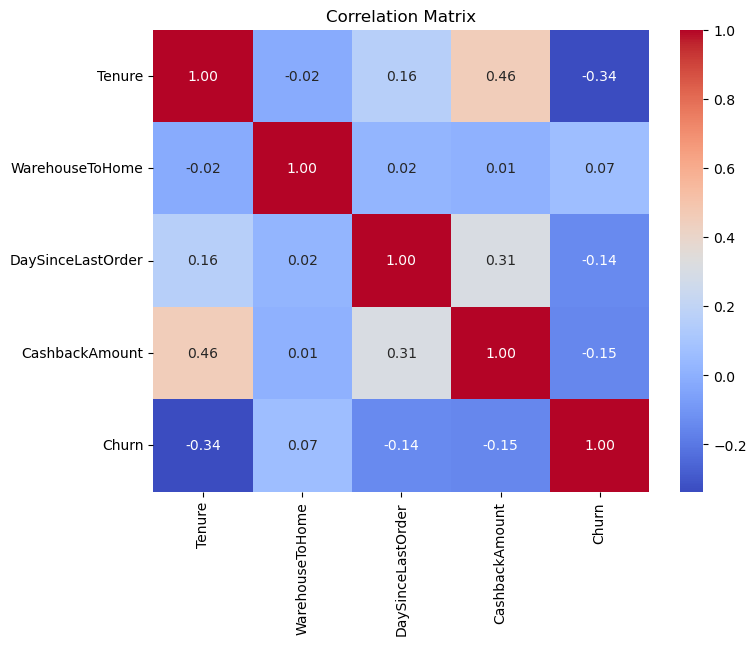

In [27]:
# 30. Correlation Analysis

correlation = df[numerical_features + ["Churn"]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [28]:
# 31. Check Categorical Columns

categorical_features = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_features))

Categorical columns:
['PreferedOrderCat', 'MaritalStatus']


In [29]:
# 32. Encode Categorical Variables

df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Categorical variables encoded successfully!")
print("New dataset shape:", df_encoded.shape)

Categorical variables encoded successfully!
New dataset shape: (3270, 16)


In [30]:
# 33. Separate Features and Target

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3270, 15)
Target shape: (3270,)


In [31]:
# 34. Split Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2616, 15)
Testing data: (654, 15)


In [32]:
# 35. Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [33]:
# 36. Make Predictions

y_pred_logistic = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred_logistic[:10])

Predictions generated successfully!
First 10 predictions: [0 0 0 0 1 1 0 0 0 1]


In [34]:
# 37. Evaluate Logistic Regression Model

from sklearn.metrics import accuracy_score, classification_report

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", round(accuracy_logistic * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 89.14 %

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       547
           1       0.73      0.53      0.62       107

    accuracy                           0.89       654
   macro avg       0.82      0.75      0.78       654
weighted avg       0.88      0.89      0.88       654



### Observation

Logistic Regression achieved 89.14% accuracy, but its recall for churned customers is 53%.

### Insight

The model performs well overall but can miss some churned customers.

In [35]:
# 38. Train Random Forest Model

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [36]:
# 39. Make Random Forest Predictions

y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred_rf[:10])

Predictions generated successfully!
First 10 predictions: [0 0 0 0 0 1 0 0 0 0]


In [37]:
# 40. Evaluate Random Forest Model

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(accuracy_rf * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 90.98 %

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       547
           1       0.77      0.64      0.70       107

    accuracy                           0.91       654
   macro avg       0.85      0.80      0.82       654
weighted avg       0.91      0.91      0.91       654



### Observation

Random Forest achieved 90.98% accuracy and a 64% recall for churned customers.

### Insight

Random Forest performs better than Logistic Regression and identifies more churned customers.

In [38]:
# 41. Compare Model Performance

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf
    ],
    "Churn Recall": [
        0.53,
        0.64
    ]
})

model_comparison["Accuracy"] = (
    model_comparison["Accuracy"] * 100
).round(2)

model_comparison["Churn Recall"] = (
    model_comparison["Churn Recall"] * 100
).round(2)

print(model_comparison)

                 Model  Accuracy  Churn Recall
0  Logistic Regression     89.14          53.0
1        Random Forest     90.98          64.0


### Observation

Random Forest performed better than Logistic Regression, with 90.98% accuracy and 64% churn recall.

### Best Model

Random Forest is selected as the final model.

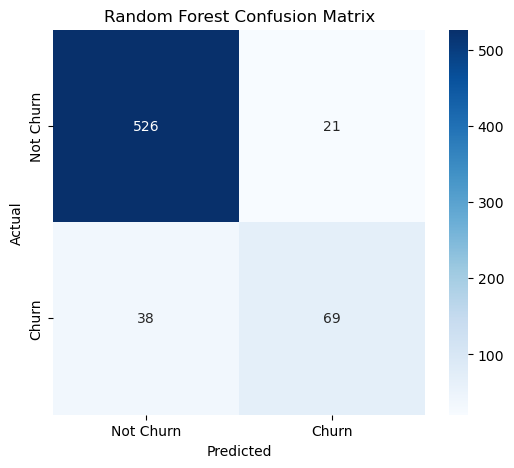

In [39]:
# 42. Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
# 43. Feature Importance

feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
Tenure                      0.244371
CashbackAmount              0.169538
WarehouseToHome             0.115741
NumberOfAddress             0.095716
DaySinceLastOrder           0.084327
Complain                    0.066920
SatisfactionScore           0.066235
NumberOfDeviceRegistered    0.053598
MaritalStatus_Single        0.028954
MaritalStatus_Married       0.018609
dtype: float64


### Observation

Tenure is the most important feature, followed by CashbackAmount and WarehouseToHome.

### Insight

Customer tenure appears to be the strongest factor used by the Random Forest model for churn prediction.

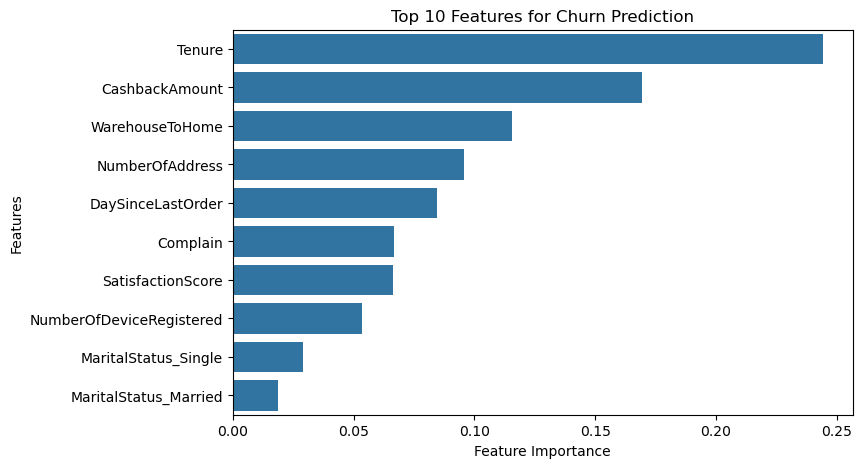

In [41]:
# 44. Visualize Feature Importance

plt.figure(figsize=(8, 5))

sns.barplot(
    x=feature_importance.head(10).values,
    y=feature_importance.head(10).index
)

plt.title("Top 10 Features for Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

In [42]:
# 45. Final Model Summary

print("Final Model: Random Forest")
print("Accuracy:", round(accuracy_rf * 100, 2), "%")
print("Churn Recall:", round(0.64 * 100, 2), "%")

Final Model: Random Forest
Accuracy: 90.98 %
Churn Recall: 64.0 %


# Final Conclusion

The Random Forest model achieved 90.98% accuracy with 64% recall for churned customers.

Tenure, CashbackAmount, and WarehouseToHome were among the most important features for predicting churn.

These insights can help businesses identify customers at higher risk of churn and improve retention strategies.